<a href="https://colab.research.google.com/github/juandguerrero/chicago-taxi-weather-analysis/blob/main/Chicago_taxi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Información df1:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB

Información df2:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
Top 10 barrios por promedio de finalización del recorrido:


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


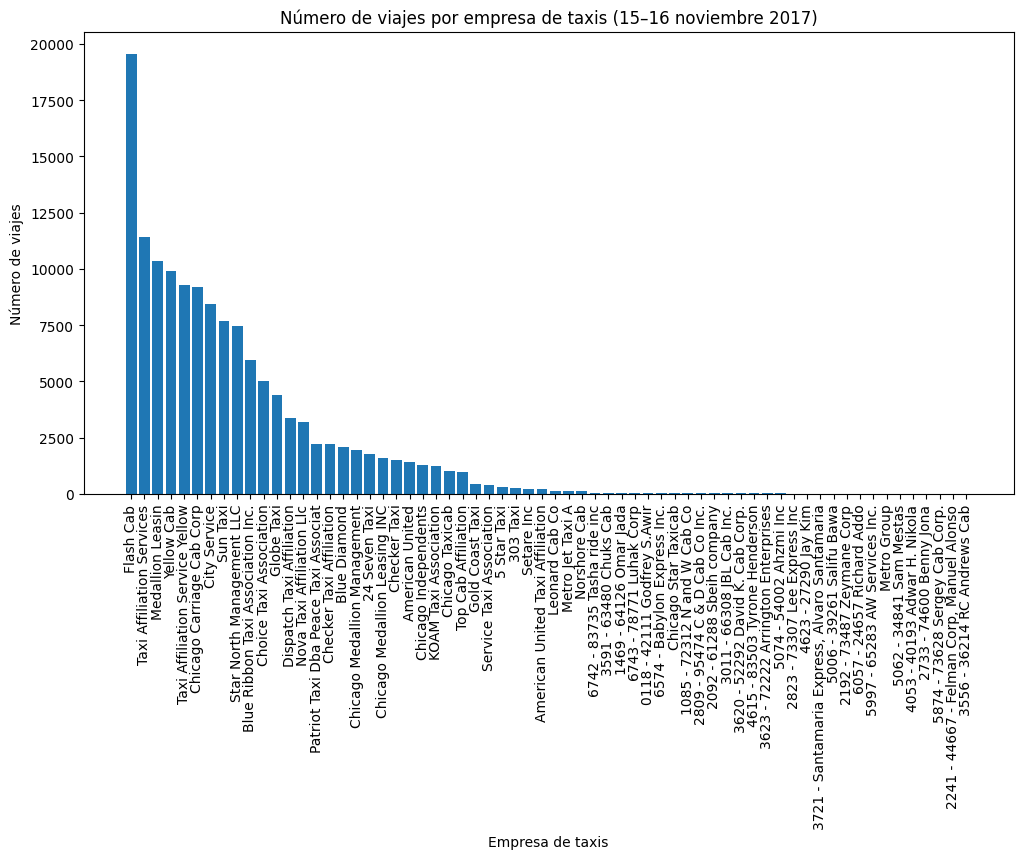

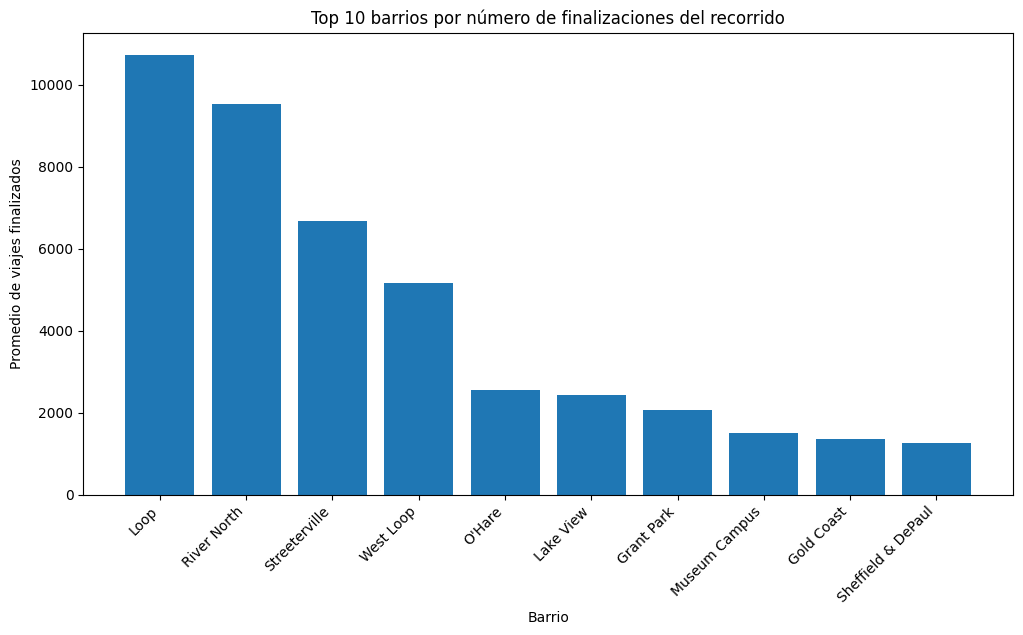

Cantidad de viajes los sábados (Bad - lluvia): 180
Cantidad de viajes los sábados (Good - sin lluvia): 888

===== RESULTADOS DEL TEST ESTADÍSTICO =====
Estadístico t: 7.186034288068629
Valor p: 6.738994326108734e-12

===== CONCLUSIÓN =====
Rechazamos la hipótesis nula (H0).
→ Sí existe una diferencia significativa en la duración promedio de los viajes entre sábados lluviosos y sábados sin lluvia.


In [11]:

# Paso 4


# 1. Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 2. Importar los archivos

df1 = pd.read_csv('project_sql_result_01.csv')
df2 = pd.read_csv('project_sql_result_04.csv')

# 3. Estudiar los datos que contienen los archivos

print("Información df1:")
print()
df1.info()
print()


print("Información df2:")
print()
df2.info()

# 4. Identificar los 10 principales barrios en términos de finalización del recorrido

# Ordenar los barrios por promedio de viajes en orden descendente
top10_barrios = df2.sort_values(by='average_trips', ascending=False).head(10)

# Mostrar los 10 barrios principales
print("Top 10 barrios por promedio de finalización del recorrido:")
display(top10_barrios)

# 5. Gráficos

# Gráfico de barras empresas de taxis vs número de viajes

# Crear figura
plt.figure(figsize=(12, 6))

# Gráfico de barras
plt.bar(df1['company_name'], df1['trips_amount'])

# Títulos y etiquetas
plt.title("Número de viajes por empresa de taxis (15–16 noviembre 2017)")
plt.xlabel("Empresa de taxis")
plt.ylabel("Número de viajes")

# Rotar etiquetas para que no se encimen
plt.xticks(rotation=90)

# Mostrar el gráfico
plt.show()

# Gráfico de barras de los 10 barrios principales por número de finalizaciones

# Seleccionar los 10 barrios con mayor average_trips
top10_barrios = df2.sort_values(by='average_trips', ascending=False).head(10)

# Crear el gráfico
plt.figure(figsize=(12, 6))
plt.bar(top10_barrios['dropoff_location_name'], top10_barrios['average_trips'])

# Títulos y etiquetas
plt.title("Top 10 barrios por número de finalizaciones del recorrido")
plt.xlabel("Barrio")
plt.ylabel("Promedio de viajes finalizados")

# Rotar etiquetas para mejor lectura
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.show()

# 6. Conclusiones

"""
Hay una empresa de taxis que se destaca de todas la demás en su número de viajes, esta es
Flash Cab, que tiene casi el doble de viajes que su competidor más cercano.
Puede ser que sea la que tenga mayor número de vehículos, la que tenga mas recorrido, o ambas.

Solo hay 14 empresas de taxis que sobrepasan el umbral de los 2500 viajes.
Probablemente la mayoría de las empresas de taxis no cuenten con muchos vehículos en su flota.

La gran mayoría de empresas tienen una cantidad de viajes insignificante.
Puede ser debido a que la mayoría de las empresas son de tamaño pequeño.

Hay cuatro Barrios con un número promedio de finalizaciones de recorridos
significativamente mayor a los demás.
Probablemente en estos barría habitan las personas de mayor poder adquísitivo,
que son las que usan el servicio de taxi con mayor frecuentcia.

El barrio con mayor número de viajes finalizados en promedio es Loop.
Probablemnte el barrío con habitantes más ricos de entre todos los observados.
"""

# Paso 5

# 1. Cargar el archivo con los datos finales
df3 = pd.read_csv('project_sql_result_07.csv')

# 2. Convertir start_ts a formato datetime
df3['start_ts'] = pd.to_datetime(df3['start_ts'])

# 3. Filtrar únicamente los viajes que ocurrieron
#    un día sábado
df_saturday = df3[df3['start_ts'].dt.dayofweek == 5]

# 4. Dividir los datos entre sábados lluviosos
#    ('Bad') y sábados sin lluvia ('Good')

rainy = df_saturday[df_saturday['weather_conditions'] == 'Bad']['duration_seconds']
non_rainy = df_saturday[df_saturday['weather_conditions'] == 'Good']['duration_seconds']

# Mostrar tamaños de cada grupo
print("Cantidad de viajes los sábados (Bad - lluvia):", len(rainy))
print("Cantidad de viajes los sábados (Good - sin lluvia):", len(non_rainy))

# 5. Prueba t de Welch (no asume varianzas iguales)
#    Hipótesis:
#    H0: las medias son iguales
#    H1: las medias son diferentes

t_stat, p_value = stats.ttest_ind(rainy, non_rainy, equal_var=False)

print("\n===== RESULTADOS DEL TEST ESTADÍSTICO =====")
print("Estadístico t:", t_stat)
print("Valor p:", p_value)

# 6. Interpretación del resultado

alpha = 0.05
print("\n===== CONCLUSIÓN =====")

if p_value < alpha:
    print("Rechazamos la hipótesis nula (H0).")
    print("→ Sí existe una diferencia significativa en la duración promedio de los viajes entre sábados lluviosos y sábados sin lluvia.")
else:
    print("No podemos rechazar la hipótesis nula (H0).")
    print("→ No hay evidencia suficiente para afirmar que la duración promedio cambie los sábados lluviosos.")




